# 電商客戶行為分析：留存追蹤與差異化行銷策略

## 專案背景及問題定義

### 資料集背景：
本分析使用 kaggle網站上的 Online Retail II 資料集，
此為一家英國電商平台於 2009-12 至 2011-12 間的交易紀錄。  
該公司主要銷售獨特的各種場合禮品，且大多數客戶為批發商。

---
### 商業情境：
在資源有限的情況下，若對所有客戶無差別採取相同行銷策略，將導致預算浪費在已高黏著度的客戶身上，同時對真正有流失風險的客戶投放力道不足。

---
### 分析目標：
本分析從客戶生命週期的兩個維度切入：
1. 客戶採購週期分析：批發商的採購週期較長，月留存率並非衡量客戶健康度的適合指標
- 透過Cohort分析觀察各批次客戶的長期採購趨勢。
2. 現有客戶分群：存活下來的客戶價值差異極大，若未能妥善分配將導致資源浪費。
- 透過 RFM 分群識別各客群價值，並制定差異化的行銷策略。

## PART 0：環境設定及載入資料
資料來源：[Kaggle Online Retail Dataset](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)    

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.2f}'.format)

import matplotlib.font_manager as fm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import platform

import pycountry

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from IPython.display import display

plt.rcParams['font.family'] = 'Arial Unicode MS'

In [36]:
# 載入資料
df = pd.read_csv('online_retail_II.csv', encoding='ISO-8859-1')

# 確認資料樣貌及型態
print(df.head(5))
print('-'*50)
print(df.info())
print('-'*50)
print(f"訂單筆數：{df['Invoice'].nunique()}")
print(f"明細筆數：{len(df)}")
print('-'*50)

# 確認空值數量
print(df.isnull().sum())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95     13085.00  United Kingdom  
1  2009-12-01 07:45:00   6.75     13085.00  United Kingdom  
2  2009-12-01 07:45:00   6.75     13085.00  United Kingdom  
3  2009-12-01 07:45:00   2.10     13085.00  United Kingdom  
4  2009-12-01 07:45:00   1.25     13085.00  United Kingdom  
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  -

## PART 1：檢查及清洗資料

#### 檢查Invoice欄位
正常為6位數字、C開頭為取消的訂單

In [37]:
# 將Invoice資料轉為文字
df['Invoice'] = df['Invoice'].astype(str)

# 分為三類 6位數字、Ｃ開頭加6位數字、其他
num = df['Invoice'].str.match(r'^\d{6}$')
cnum = df['Invoice'].str.match(r'^C\d{6}$')
other = ~df['Invoice'].str.match(r'^\d{6}$|^C\d{6}$')

# 確認三類訂單數量
print(f"6位數字：{df[num]['Invoice'].nunique()} 筆訂單")
print(f"Ｃ開頭加6位數字：{df[cnum]['Invoice'].nunique()} 筆訂單")
print(f"其他：{df[other]['Invoice'].nunique()} 筆訂單")
print('-'*50)

# 檢查分到其他的訂單資料型態
print(df[other])

6位數字：45330 筆訂單
Ｃ開頭加6位數字：8292 筆訂單
其他：6 筆訂單
--------------------------------------------------
        Invoice StockCode      Description  Quantity          InvoiceDate  \
179403  A506401         B  Adjust bad debt         1  2010-04-29 13:36:00   
276274  A516228         B  Adjust bad debt         1  2010-07-19 11:24:00   
403472  A528059         B  Adjust bad debt         1  2010-10-20 12:04:00   
825443  A563185         B  Adjust bad debt         1  2011-08-12 14:50:00   
825444  A563186         B  Adjust bad debt         1  2011-08-12 14:51:00   
825445  A563187         B  Adjust bad debt         1  2011-08-12 14:52:00   

           Price  Customer ID         Country  
179403 -53594.36          NaN  United Kingdom  
276274 -44031.79          NaN  United Kingdom  
403472 -38925.87          NaN  United Kingdom  
825443  11062.06          NaN  United Kingdom  
825444 -11062.06          NaN  United Kingdom  
825445 -11062.06          NaN  United Kingdom  


##### 觀察結果
- 由Description發現分到其他的6筆資料皆為A開頭，為呆帳並非分析範圍，可刪除

#### 檢查StockCode欄位
正常為5位數字或5位數字加一個英文(表示顏色、尺寸等)

In [38]:
# 先標示出正常情況，再檢查不正常資料的型態
nor_code = df['StockCode'].astype(str).str.match(r'^\d{5}$|^\d{5}[A-Za-z]+$')
unnor_code = ~df['StockCode'].astype(str).str.match(r'^\d{5}$|^\d{5}[A-Za-z]+$')

print(f"正常筆數：{len(df[nor_code])}筆明細")
print(f"不正常筆數：{len(df[unnor_code])}筆明細")
print('-'*50)

# 檢查分到不正常的資料型態
df[unnor_code]['StockCode'].value_counts()

正常筆數：1061277筆明細
不正常筆數：6094筆明細
--------------------------------------------------


StockCode
POST            2122
DOT             1446
M               1421
C2               282
D                177
S                104
BANK CHARGES     102
ADJUST            67
AMAZONFEE         43
DCGS0058          31
gift_0001_20      29
gift_0001_30      29
DCGSSGIRL         25
DCGSSBOY          23
PADS              19
gift_0001_10      16
CRUK              16
DCGS0076          15
TEST001           15
DCGS0003          14
gift_0001_50       8
gift_0001_40       7
DCGS0069           6
B                  6
DCGS0004           5
m                  5
DCGS0066N          4
DCGS0072           4
gift_0001_80       4
ADJUST2            3
DCGS0070           3
gift_0001_70       3
SP1002             3
DCGS0068           3
DCGS0037           2
TEST002            2
DCGS0062           2
gift_0001_90       2
gift_0001_60       2
GIFT               1
DCGS0067           1
DCGS0066P          1
DCGS0071           1
DCGS0073           1
DCGS0057           1
DCGS0074           1
DCGS0055           1
DCG

##### 觀察結果
- 只有DCGS開頭為特定商品需保留
- 其他（包含運費、商品卡、折扣、樣本、測試等等）皆刪除

#### 檢查Quantity欄位
正常應為正數，除非為Invoice為C開頭的取消訂單

In [39]:
# 因Quantity為數值型資料，先檢查基本統計資訊
print(df["Quantity"].describe())
print('-'*50)

# 找出正值、負值、零值各有多少筆
print(f"正數明細筆數：{(df['Quantity'] > 0).sum()}")
print(f"負數明細筆數：{(df['Quantity'] < 0).sum()}")
print(f"零值明細筆數：{(df['Quantity'] == 0).sum()}")
print('-'*50)

# 檢查Quantity<0資料的Invoice情況
# C開頭的取消訂單Quantity應為負數，先檢查
c_start = df['Invoice'].astype(str).str.startswith("C")

print(f"Invoice為C開頭且Quantity為負數的明細筆數：{(c_start & (df['Quantity'] < 0)).sum()}")
print(f"Invoice為純數字且Quantity為負數的明細筆數：{(~c_start & (df['Quantity'] < 0)).sum()}")
print('-'*50)

# 發現Invoice欄位為Ｃ開頭的共有19494筆，同時Quantity為負數的有19493筆
# 確認nvoice欄位為Ｃ開頭且Quantity為正數的這筆資料
print(df[(c_start & (df['Quantity'] > 0))])
print('-'*50)

# 接著確認Invoice為純數字且Quantity為負的資料Description欄位樣貌
mask = (~c_start & (df['Quantity'] < 0))
print(df[mask]['Description'].value_counts())

count   1067371.00
mean          9.94
std         172.71
min      -80995.00
25%           1.00
50%           3.00
75%          10.00
max       80995.00
Name: Quantity, dtype: float64
--------------------------------------------------
正數明細筆數：1044421
負數明細筆數：22950
零值明細筆數：0
--------------------------------------------------
Invoice為C開頭且Quantity為負數的明細筆數：19493
Invoice為純數字且Quantity為負數的明細筆數：3457
--------------------------------------------------
       Invoice StockCode Description  Quantity          InvoiceDate  Price  \
76799  C496350         M      Manual         1  2010-02-01 08:24:00 373.57   

       Customer ID         Country  
76799          NaN  United Kingdom  
--------------------------------------------------
Description
check                                  123
damages                                 84
?                                       83
damaged                                 78
missing                                 27
sold as set on dotcom                   20
Damage

##### 觀察結果
- 由基本統計資料可看出有負值並不正常
- 發現有一筆Invoice欄位為Ｃ開頭的資料Quantity為正數，檢查後發現StockCode為M，為手動調整訂單需刪除
- 由Description欄位檢查後確認剩下的並非真實客戶交易，因此Quantity為負的資料皆可刪除


#### 檢查InvoiceDate欄位

In [40]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"最早日期：{df['InvoiceDate'].min()}")
print(f"最晚日期：{df['InvoiceDate'].max()}")

最早日期：2009-12-01 07:45:00
最晚日期：2011-12-09 12:50:00


##### 觀察結果
- 資料最後一天只到12/9，並非完整到月底，後續分析時需注意

#### 檢查Price欄位
正常應為正數

In [41]:
# 因Price為數值型資料，先檢查基本統計資訊
print(df["Price"].describe())
# 可看出有負值
print('-'*50)

# 找出正值、負值、零值各有多少筆
print(f"價格為正的明細筆數：{(df['Price']>0).sum()}")
print(f"價格為零的明細筆數：{(df['Price']==0).sum()}")
print(f"價格為負的明細筆數：{(df['Price']<0).sum()}")
print('-'*50)

# 檢查零元商品
print(df[df['Price']==0]['Description'].value_counts().head(10).to_string())
print('-'*50)

# 檢查異常高價（前十高價）商品
print(df[df['Price']>0].sort_values('Price',ascending=False).head(10).to_string())
print('-'*50)

# 檢查價格為負的商品
print(df[df['Price']<0].to_string())

count   1067371.00
mean          4.65
std         123.55
min      -53594.36
25%           1.25
50%           2.10
75%           4.15
max       38970.00
Name: Price, dtype: float64
--------------------------------------------------
價格為正的明細筆數：1061164
價格為零的明細筆數：6202
價格為負的明細筆數：5
--------------------------------------------------
Description
check                    162
?                         92
damages                   84
damaged                   81
found                     28
missing                   27
sold as set on dotcom     20
Damaged                   17
adjustment                16
OWL DOORSTOP              15
--------------------------------------------------
         Invoice     StockCode   Description  Quantity         InvoiceDate    Price  Customer ID         Country
748142   C556445             M        Manual        -1 2011-06-10 15:31:00 38970.00     15098.00  United Kingdom
241824   C512770             M        Manual        -1 2010-06-17 16:52:00 25111.09     17399.

##### 觀察結果
- Price欄位有6202筆交易為0元、5筆為負數，0元交易檢查Description欄位後確認並非真實交易、5筆負數交易皆為呆帳，皆可刪除
- 檢查價格異常高的交易，發現非真實交易資料，在Invoice或Stockcode清理時已經刪除

#### 檢查Customer ID欄位

In [42]:
print(df['Customer ID'].describe())
print(f"不重複客戶數:{df['Customer ID'].nunique()}")
print('-'*50)

# 將資料型態轉為整數
df['Customer ID'] = df['Customer ID'].astype('Int64')

print(f"缺失明細筆數:{df['Customer ID'].isnull().sum()}")
print(f"缺失訂單數:{df[df['Customer ID'].isnull()]['Invoice'].nunique()}")
print('-'*50)

print(f"Price為零:{df[df['Customer ID'].isnull() & (df['Price']==0)]['Invoice'].nunique()}筆訂單")
print(f"Quantity為負數:{df[df['Customer ID'].isnull() & (df['Quantity']<0)]['Invoice'].nunique()}筆訂單")
print(f"Invoice為C開頭:{df[df['Customer ID'].isnull() & df['Invoice'].astype(str).str.startswith('C')]['Invoice'].nunique()}筆訂單")
print('-'*50)
# 檢查後確認空值原因可能為非正常交易訂單（包含1.price=0 2.quantity<0 3.Invoice為C開頭 ）

# 確認並非以上三個條件且Customer ID缺失的訂單筆數
mask = (
    df['Customer ID'].isnull() &
    (df['Price'] != 0) &
    (df['Quantity'] >= 0) &
    (~df['Invoice'].astype(str).str.startswith('C'))
)
print(f"其他缺失訂單筆數：{df[mask]['Invoice'].nunique()}")
print(f"其他缺失明細筆數：{mask.sum()}")

count   824364.00
mean     15324.64
std       1697.46
min      12346.00
25%      13975.00
50%      15255.00
75%      16797.00
max      18287.00
Name: Customer ID, dtype: float64
不重複客戶數:5942
--------------------------------------------------
缺失明細筆數:243007
缺失訂單數:8752
--------------------------------------------------
Price為零:5318筆訂單
Quantity為負數:3783筆訂單
Invoice為C開頭:391筆訂單
--------------------------------------------------
其他缺失訂單筆數：3113
其他缺失明細筆數：236126


##### 觀察結果
- Customer ID 缺失原因可能為 1.price=0 2.quantity<0 3.Invoice為C開頭 4.未登入的顧客
- Customer ID 缺失訂單筆數共8752筆
- Customer ID 缺失原因可能為未登入的訂單筆數共3113筆

#### 檢查Country欄位

In [43]:
print(df['Country'].value_counts())
# 因國家並非分析重點，故不清理資料

"""
print('-'*50)
# 若有分析需求可進一步確認哪些國家可能標示錯誤
# 取得所有國家名稱
valid_countries = {country.name for country in pycountry.countries}
# 找出不在名單中的資料
invalid = df[~df['Country'].isin(valid_countries)]['Country'].value_counts()
print('不在名單中的資料')
print(invalid)
"""

Country
United Kingdom          981330
EIRE                     17866
Germany                  17624
France                   14330
Netherlands               5140
Spain                     3811
Switzerland               3189
Belgium                   3123
Portugal                  2620
Australia                 1913
Channel Islands           1664
Italy                     1534
Norway                    1455
Sweden                    1364
Cyprus                    1176
Finland                   1049
Austria                    938
Denmark                    817
Unspecified                756
Greece                     663
Japan                      582
Poland                     535
USA                        535
United Arab Emirates       500
Israel                     371
Hong Kong                  364
Singapore                  346
Malta                      299
Iceland                    253
Canada                     228
Lithuania                  189
RSA                        169


"\nprint('-'*50)\n# 若有分析需求可進一步確認哪些國家可能標示錯誤\n# 取得所有國家名稱\nvalid_countries = {country.name for country in pycountry.countries}\n# 找出不在名單中的資料\ninvalid = df[~df['Country'].isin(valid_countries)]['Country'].value_counts()\nprint('不在名單中的資料')\nprint(invalid)\n"

### 清洗資料

#### 統整各欄位需要清洗的條件 :

| 欄位 | 條件 |
|---|---|
|Invoice|刪除A、C開頭的資料|
|StockCode|只保留合格的格式(5位數字、5位數字+英文、DCGS 開頭)|
|Quantity|只保留正數的資料|
|Price|只保留正數的資料|
|Customer ID|刪除為遺失值的資料|

In [44]:
### 清洗Invoice欄位
# 將A開頭和C開頭的刪除
mask_remove = (
    df['Invoice'].astype(str).str.startswith('A') |
    df['Invoice'].astype(str).str.startswith('C')
)
df = df[~mask_remove].reset_index(drop=True)

### 清洗StockCode欄位
sc = df['StockCode'].astype(str)
# 留下合格的格式
mask_keep = (
    sc.str.match(r'^\d{5}$') |           # 5位數字
    sc.str.match(r'^\d{5}[A-Za-z]+$') |  # 5位數字 + 英文
    sc.str.match(r'^DCGS')                # DCGS 開頭
)
df = df[mask_keep].reset_index(drop=True)

### 清洗Quantity欄位
# 只保留Quantity為正數的資料
df = df[df['Quantity'] > 0].reset_index(drop=True)

### 清洗Price欄位
# 只保留Price為正數的資料
df = df[df['Price'] > 0].reset_index(drop=True)

### 清洗Customer ID欄位
# 將空值的資料全刪除
df = df[df['Customer ID'].notna()].reset_index(drop=True)

### 因國家並非分析重點，故不清洗資料

In [45]:
# 檢查清洗後的資料型態
print(df.info())
print('-'*50)
print(f"清洗後的訂單筆數：{df['Invoice'].nunique()}")
print(f"清洗後的明細筆數：{len(df)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 802632 entries, 0 to 802631
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      802632 non-null  object        
 1   StockCode    802632 non-null  object        
 2   Description  802632 non-null  object        
 3   Quantity     802632 non-null  int64         
 4   InvoiceDate  802632 non-null  datetime64[ns]
 5   Price        802632 non-null  float64       
 6   Customer ID  802632 non-null  Int64         
 7   Country      802632 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 49.8+ MB
None
--------------------------------------------------
清洗後的訂單筆數：36594
清洗後的明細筆數：802632


## PART 2：探索性分析(EDA)

#### 業務概況
- 月營收趨勢
- 月訂單數趨勢

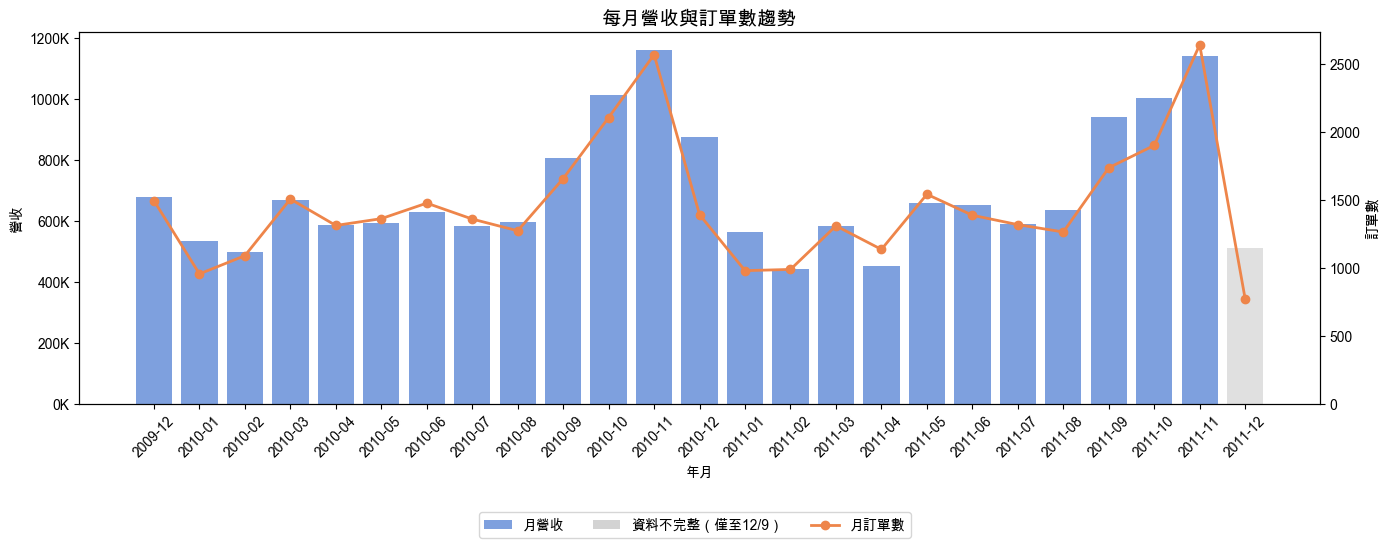

In [46]:
## 整理所需資料
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Revenue'] = df['Quantity'] * df['Price']

monthly = df.groupby('YearMonth').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('Invoice', 'nunique'),
).reset_index()
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

# 將不完整的月份設定為灰色
incomplete_month = '2011-12'
colors_revenue  = [sns.color_palette('muted')[0] if m != incomplete_month else 'lightgray' for m in monthly['YearMonth']]

## 做圖
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# 營收（左軸，長條圖）
ax1.bar(monthly['YearMonth'], monthly['Revenue'],
        color=colors_revenue, alpha=0.7, label='月營收')

# 訂單數（右軸，折線圖）
ax2.plot(monthly['YearMonth'], monthly['Orders'],
         color=sns.color_palette('muted')[1],
         marker='o', linewidth=2, label='月訂單數')

# 軸線
ax1.set_xlabel('年月')
ax1.set_ylabel('營收')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax1.tick_params(axis='x', rotation=45)

ax2.set_ylabel('訂單數')
ax2.set_ylim(bottom=0)

# 標題
plt.title('每月營收與訂單數趨勢', fontsize=14)

# 圖例
legend_elements = [
    Patch(facecolor=sns.color_palette('muted')[0], alpha=0.7, label='月營收'),
    Patch(facecolor='lightgray', label='資料不完整（僅至12/9）'),
    Line2D([0], [0], color=sns.color_palette('muted')[1],
           marker='o', linewidth=2, label='月訂單數')
]
fig.legend(handles=legend_elements, loc='upper center',
           bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=10)

plt.tight_layout()
plt.show()

#### 客戶採購行為分析
- 客戶平均採購間隔分布
- 每月新客數趨勢

可計算採購間隔的客戶數：4,234 位
平均採購間隔中位數：72 天
平均採購間隔平均數：103 天


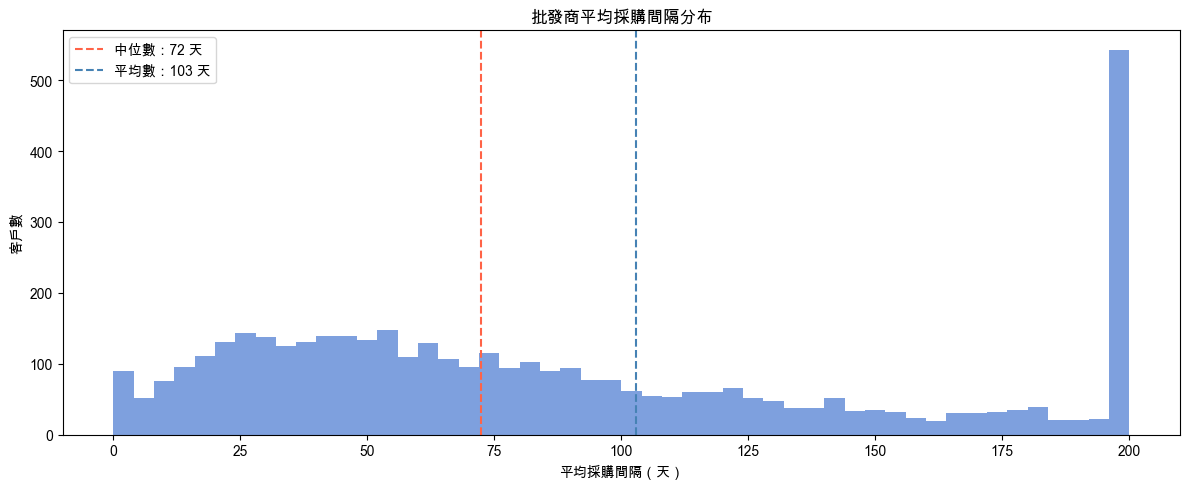

In [47]:
### 客戶平均採購間隔分布

customer_intervals = (
    df.groupby('Customer ID')
    .apply(lambda x: x.drop_duplicates('Invoice')
           .sort_values('InvoiceDate')['InvoiceDate']
           .diff().dt.days.mean())
    .reset_index()
)
customer_intervals.columns = ['Customer ID', 'AvgDaysBetweenOrders']
customer_intervals = customer_intervals.dropna()  # 只有一筆訂單的客戶無法計算間隔

median_interval = customer_intervals['AvgDaysBetweenOrders'].median()
mean_interval   = customer_intervals['AvgDaysBetweenOrders'].mean()

print(f"可計算採購間隔的客戶數：{len(customer_intervals):,} 位")
print(f"平均採購間隔中位數：{median_interval:.0f} 天")
print(f"平均採購間隔平均數：{mean_interval:.0f} 天")

# 視覺化
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(
    customer_intervals['AvgDaysBetweenOrders'].clip(upper=200),
    bins=50, color=sns.color_palette('muted')[0], alpha=0.7
)
ax.axvline(median_interval, color='tomato', linestyle='--',
           linewidth=1.5, label=f'中位數：{median_interval:.0f} 天')
ax.axvline(mean_interval, color='steelblue', linestyle='--',
           linewidth=1.5, label=f'平均數：{mean_interval:.0f} 天')
ax.set_xlabel('平均採購間隔（天）')
ax.set_ylabel('客戶數')
ax.set_title('批發商平均採購間隔分布')
ax.legend()
plt.tight_layout()
plt.show()

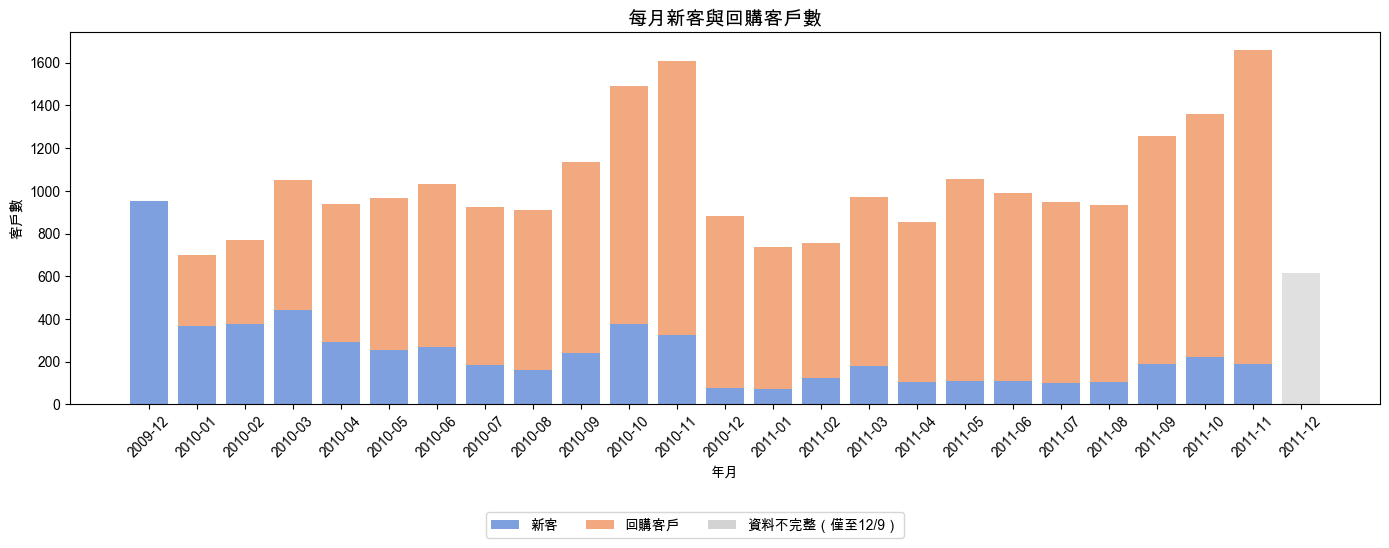

In [48]:
# 每月新客數趨勢

# 每位客戶的首購月份
first_purchase = (
    df.groupby('Customer ID')['InvoiceDate']
    .min()
    .dt.to_period('M')
    .reset_index()
)
first_purchase.columns = ['Customer ID', 'FirstMonth']
first_purchase['FirstMonth'] = first_purchase['FirstMonth'].astype(str)

# 每月新客數
new_customers = (
    first_purchase.groupby('FirstMonth')['Customer ID']
    .count()
    .reset_index()
)
new_customers.columns = ['YearMonth', 'NewCustomers']

# 每月活躍客戶數
monthly_active = (
    df.groupby('YearMonth')['Customer ID']
    .nunique()
    .reset_index()
)
monthly_active.columns = ['YearMonth', 'ActiveCustomers']

monthly_active['YearMonth'] = monthly_active['YearMonth'].astype(str)
new_customers['YearMonth'] = new_customers['YearMonth'].astype(str)

# 合併，計算回購客戶數
monthly_combined = monthly_active.merge(new_customers, on='YearMonth', how='left')
monthly_combined['ReturnCustomers'] = (
    monthly_combined['ActiveCustomers'] - monthly_combined['NewCustomers']
)

# 設定顏色
COLOR_NEW      = sns.color_palette('muted')[0]
COLOR_RETURN   = sns.color_palette('muted')[1]
INCOMPLETE_MONTH = '2011-12'
colors_new = [
    COLOR_NEW if m != INCOMPLETE_MONTH else 'lightgray'
    for m in monthly_combined['YearMonth']
]
colors_return = [
    COLOR_RETURN if m != INCOMPLETE_MONTH else 'lightgray'
    for m in monthly_combined['YearMonth']
]


# 做圖
fig, ax = plt.subplots(figsize=(14, 5))

# 新客（下層）
ax.bar(monthly_combined['YearMonth'],
       monthly_combined['NewCustomers'],
       color=colors_new, alpha=0.7)

# 回購客戶（上層）
ax.bar(monthly_combined['YearMonth'],
       monthly_combined['ReturnCustomers'],
       bottom=monthly_combined['NewCustomers'],
       color=colors_return, alpha=0.7)

ax.set_xlabel('年月')
ax.set_ylabel('客戶數')
ax.tick_params(axis='x', rotation=45)
plt.title('每月新客與回購客戶數', fontsize=14)

# 圖例
legend_elements = [
    Patch(facecolor=COLOR_NEW,    alpha=0.7, label='新客'),
    Patch(facecolor=COLOR_RETURN, alpha=0.7, label='回購客戶'),
    Patch(facecolor='lightgray',             label='資料不完整（僅至12/9）')
]
fig.legend(handles=legend_elements, loc='upper center',
           bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=10)

plt.tight_layout()
plt.show()

#### 客戶消費行為
- 客單價分布
- 訂單頻率分布
- 熱銷商品 Top10
- 地區營收分佈

count    36594.00
mean       476.43
std       1374.24
min          0.38
25%        161.60
50%        304.65
75%        485.64
max     168469.60
Name: OrderRevenue, dtype: float64


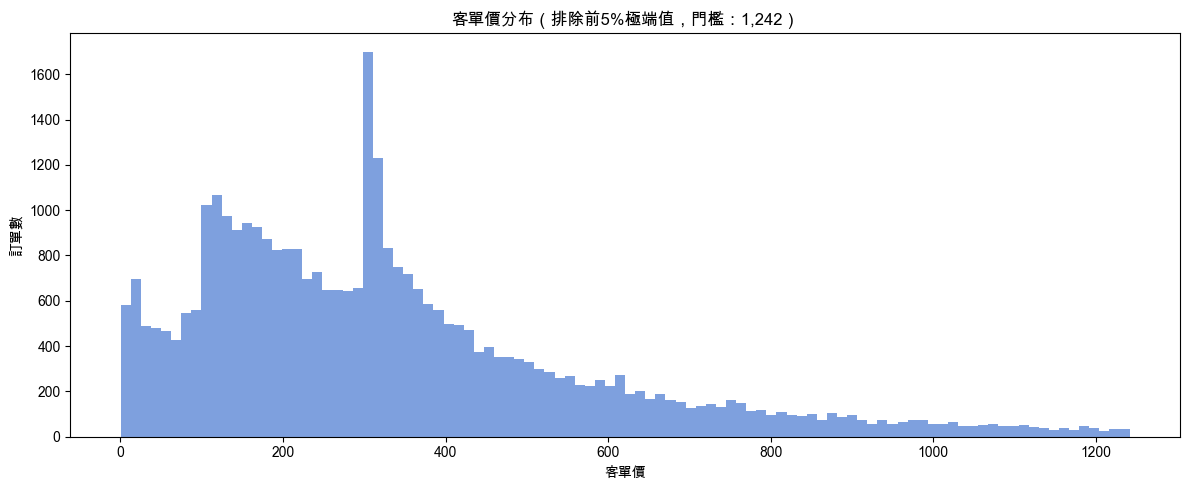

中位數：305
平均數：476
客單價 500 以下比例：76.1%


In [49]:
# 客單價分布

# 計算每張訂單的總金額
order_revenue = df.groupby('Invoice')['Revenue'].sum().reset_index()
order_revenue.columns = ['Invoice', 'OrderRevenue']

# 描述性統計
print(order_revenue['OrderRevenue'].describe())
# 可觀察到離群值非常大，先排除前5%的離群值再做圖

OR_p95 = order_revenue['OrderRevenue'].quantile(0.95)

order_revenue_clipped = order_revenue[order_revenue['OrderRevenue'] <= OR_p95]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(order_revenue_clipped['OrderRevenue'], bins=100,
        color=sns.color_palette('muted')[0], alpha=0.7)
ax.set_xlabel('客單價')
ax.set_ylabel('訂單數')
ax.set_title(f'客單價分布（排除前5%極端值，門檻：{OR_p95:,.0f}）')
plt.tight_layout()
plt.show()


median  = order_revenue['OrderRevenue'].median()
mean    = order_revenue['OrderRevenue'].mean()
pct_under_500 = (order_revenue['OrderRevenue'] <= 500).mean()

print(f"中位數：{median:,.0f}")
print(f"平均數：{mean:,.0f}")
print(f"客單價 500 以下比例：{pct_under_500:.1%}")

count   5852.00
mean       6.25
std       12.75
min        1.00
25%        1.00
50%        3.00
75%        7.00
max      373.00
Name: OrderFrequency, dtype: float64


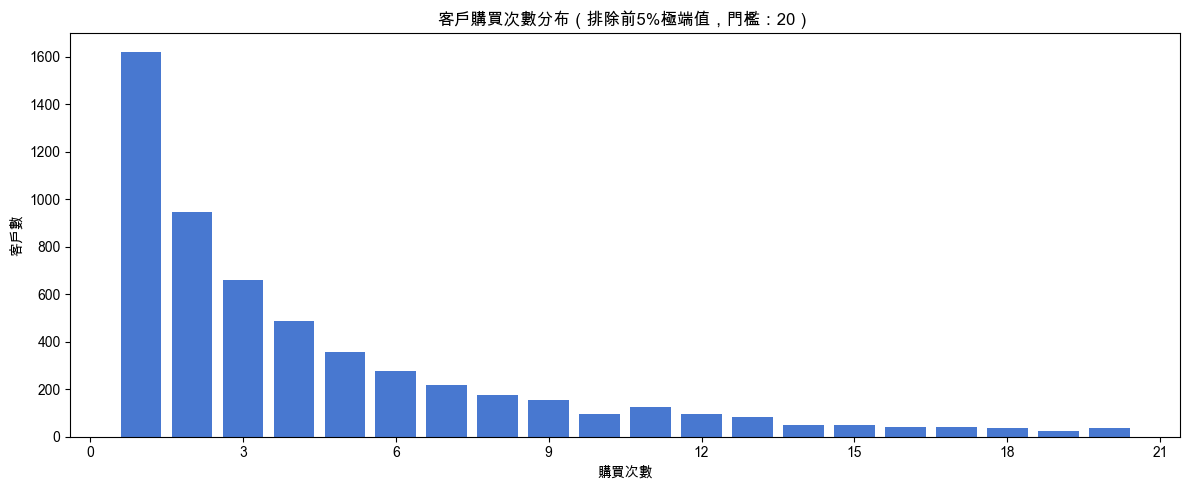

中位數：3
平均數：6


In [50]:
# 訂單頻率分布

order_frequency = df.groupby('Customer ID')['Invoice'].nunique().reset_index()
order_frequency.columns = ['Customer ID', 'OrderFrequency']

# 描述性統計
print(order_frequency['OrderFrequency'].describe())
# 可觀察到離群值非常大，故先排除前5%的離群值再做圖

OF_p95 = order_frequency['OrderFrequency'].quantile(0.95)

order_frequency_clipped = order_frequency[order_frequency['OrderFrequency'] <= OF_p95]['OrderFrequency'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(order_frequency_clipped.index, order_frequency_clipped.values, color=sns.color_palette('muted')[0])
ax.set_xlabel('購買次數')
ax.set_ylabel('客戶數')
ax.set_title(f'客戶購買次數分布（排除前5%極端值，門檻：{OF_p95:,.0f}）')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


median  = order_frequency['OrderFrequency'].median()
mean    = order_frequency['OrderFrequency'].mean()

print(f"中位數：{median:,.0f}")
print(f"平均數：{mean:,.0f}")

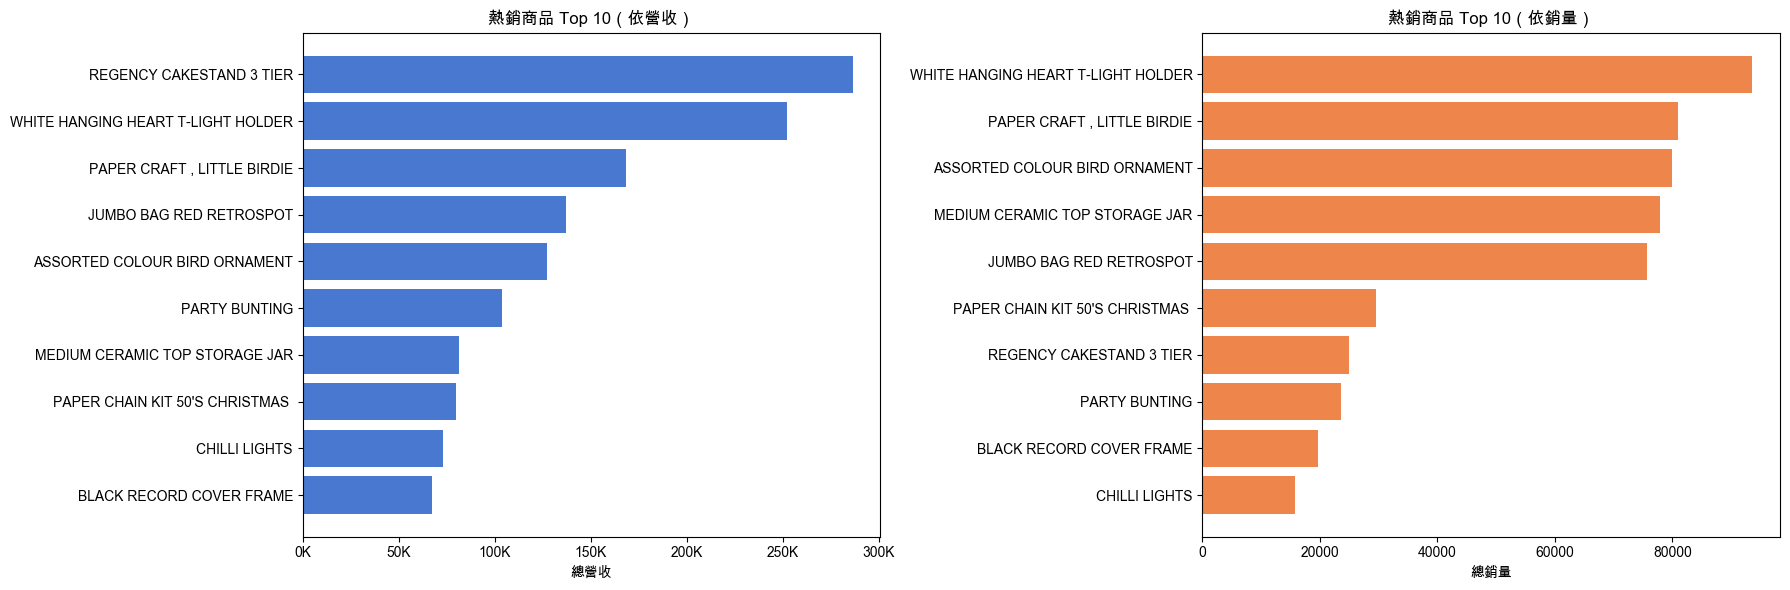

In [51]:
# 熱銷商品 Top10

top_products = df.groupby(['StockCode', 'Description']).agg(
    總營收=('Revenue', 'sum'),
    總銷量=('Quantity', 'sum'),
    購買人數=('Customer ID', 'nunique')
).reset_index().sort_values('總營收', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 依營收排序
top_rev = top_products.sort_values('總營收')
axes[0].barh(top_rev['Description'], top_rev['總營收'],
             color=sns.color_palette('muted')[0])
axes[0].set_title('熱銷商品 Top 10（依營收）')
axes[0].set_xlabel('總營收')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# 依銷量排序
top_qty = top_products.sort_values('總銷量')
axes[1].barh(top_qty['Description'], top_qty['總銷量'],
             color=sns.color_palette('muted')[1])
axes[1].set_title('熱銷商品 Top 10（依銷量）')
axes[1].set_xlabel('總銷量')

plt.tight_layout()
plt.show()

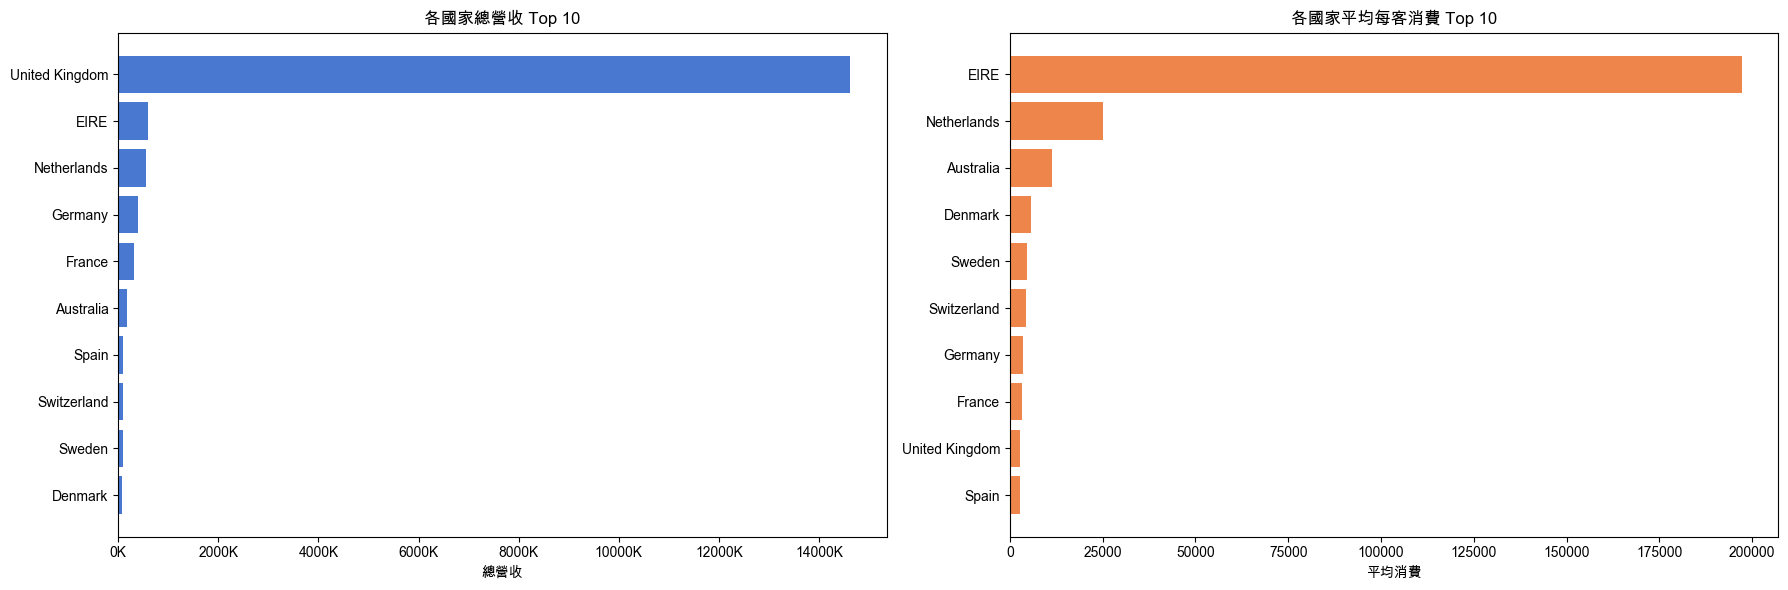

,Country,總營收,客戶數,訂單數,營收佔比(%),平均每客消費
0,United Kingdom,14622043.45,5334,33361,83.87,2741.29
1,EIRE,591536.65,3,528,3.39,197178.88
2,Netherlands,549952.66,22,216,3.15,24997.85
3,Germany,388829.75,107,753,2.23,3633.92
4,France,315261.67,93,590,1.81,3389.91
5,Australia,168484.66,15,89,0.97,11232.31
6,Spain,98612.79,38,144,0.57,2595.07
7,Switzerland,93624.34,22,82,0.54,4255.65
8,Sweden,86079.04,19,98,0.49,4530.48
9,Denmark,68560.19,12,42,0.39,5713.35


In [52]:
# 地區營收分佈

country_stats = df.groupby('Country').agg(
    總營收=('Revenue', 'sum'),
    客戶數=('Customer ID', 'nunique'),
    訂單數=('Invoice', 'nunique')
).reset_index().sort_values('總營收', ascending=False).head(10)
country_stats['營收佔比(%)'] = (country_stats['總營收'] / df['Revenue'].sum() * 100).round(2)
country_stats['平均每客消費'] = (country_stats['總營收'] / country_stats['客戶數']).round(2)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 各國營收
top_c = country_stats.sort_values('總營收')
axes[0].barh(top_c['Country'], top_c['總營收'],
             color=sns.color_palette('muted')[0])
axes[0].set_title('各國家總營收 Top 10')
axes[0].set_xlabel('總營收')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# 各國平均每客消費
top_avg = country_stats.sort_values('平均每客消費')
axes[1].barh(top_avg['Country'], top_avg['平均每客消費'],
             color=sns.color_palette('muted')[1])
axes[1].set_title('各國家平均每客消費 Top 10')
axes[1].set_xlabel('平均消費')

plt.tight_layout()
plt.show()

display(country_stats.reset_index(drop=True))

#### 探索性分析發現幾個現象：
- 營收高度集中第四季，推測與節慶購物季有關，後續的Cohort分析中可再觀察新客的留存行為。
- 訂單數趨勢與營收趨勢走勢一致，代表營收成長主要來自訂單量增加而非客單價提升。
- 批發商的採購間隔遠高於一般零售消費者，月留存率偏低是正常的採購節奏反映，不應以零售業標準解讀為客戶流失。
- 客戶消費行為呈現明顯的右偏分布，少數高頻高消費客戶貢獻了高額的營收，凸顯了 RFM 差異化分群的必要性。
- 熱銷商品集中於家居裝飾與禮品類，可作為後續行銷時的推薦商品基礎。
- 高度依賴英國本土市場，國際市場尚處於早期階段。

## PART 3：Cohort 分析

In [53]:
# 排除 2011-12 的不完整資料
df_co = df[df['InvoiceDate'] < '2011-12-01'].reset_index(drop=True)

# 1. 建立 Cohort 欄位
df_co['CohortMonth'] = df_co.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')
df_co['OrderMonth']  = df_co['InvoiceDate'].dt.to_period('M')
df_co['CohortIndex'] = (df_co['OrderMonth'] - df_co['CohortMonth']).apply(lambda x: x.n)

# 2. 計算各 Cohort 每月不重複客戶數
cohort_data  = df_co.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

# 3. 計算留存率
cohort_size = cohort_pivot[0]
retention   = cohort_pivot.divide(cohort_size, axis=0).round(4)

print(f'Cohort 數量：{len(retention)} 個月')
print(f'追蹤月數：{len(retention.columns)} 個月')
print(f'平均初始 Cohort 人數：{cohort_size.mean():.0f} 位')

Cohort 數量：24 個月
追蹤月數：24 個月
平均初始 Cohort 人數：243 位


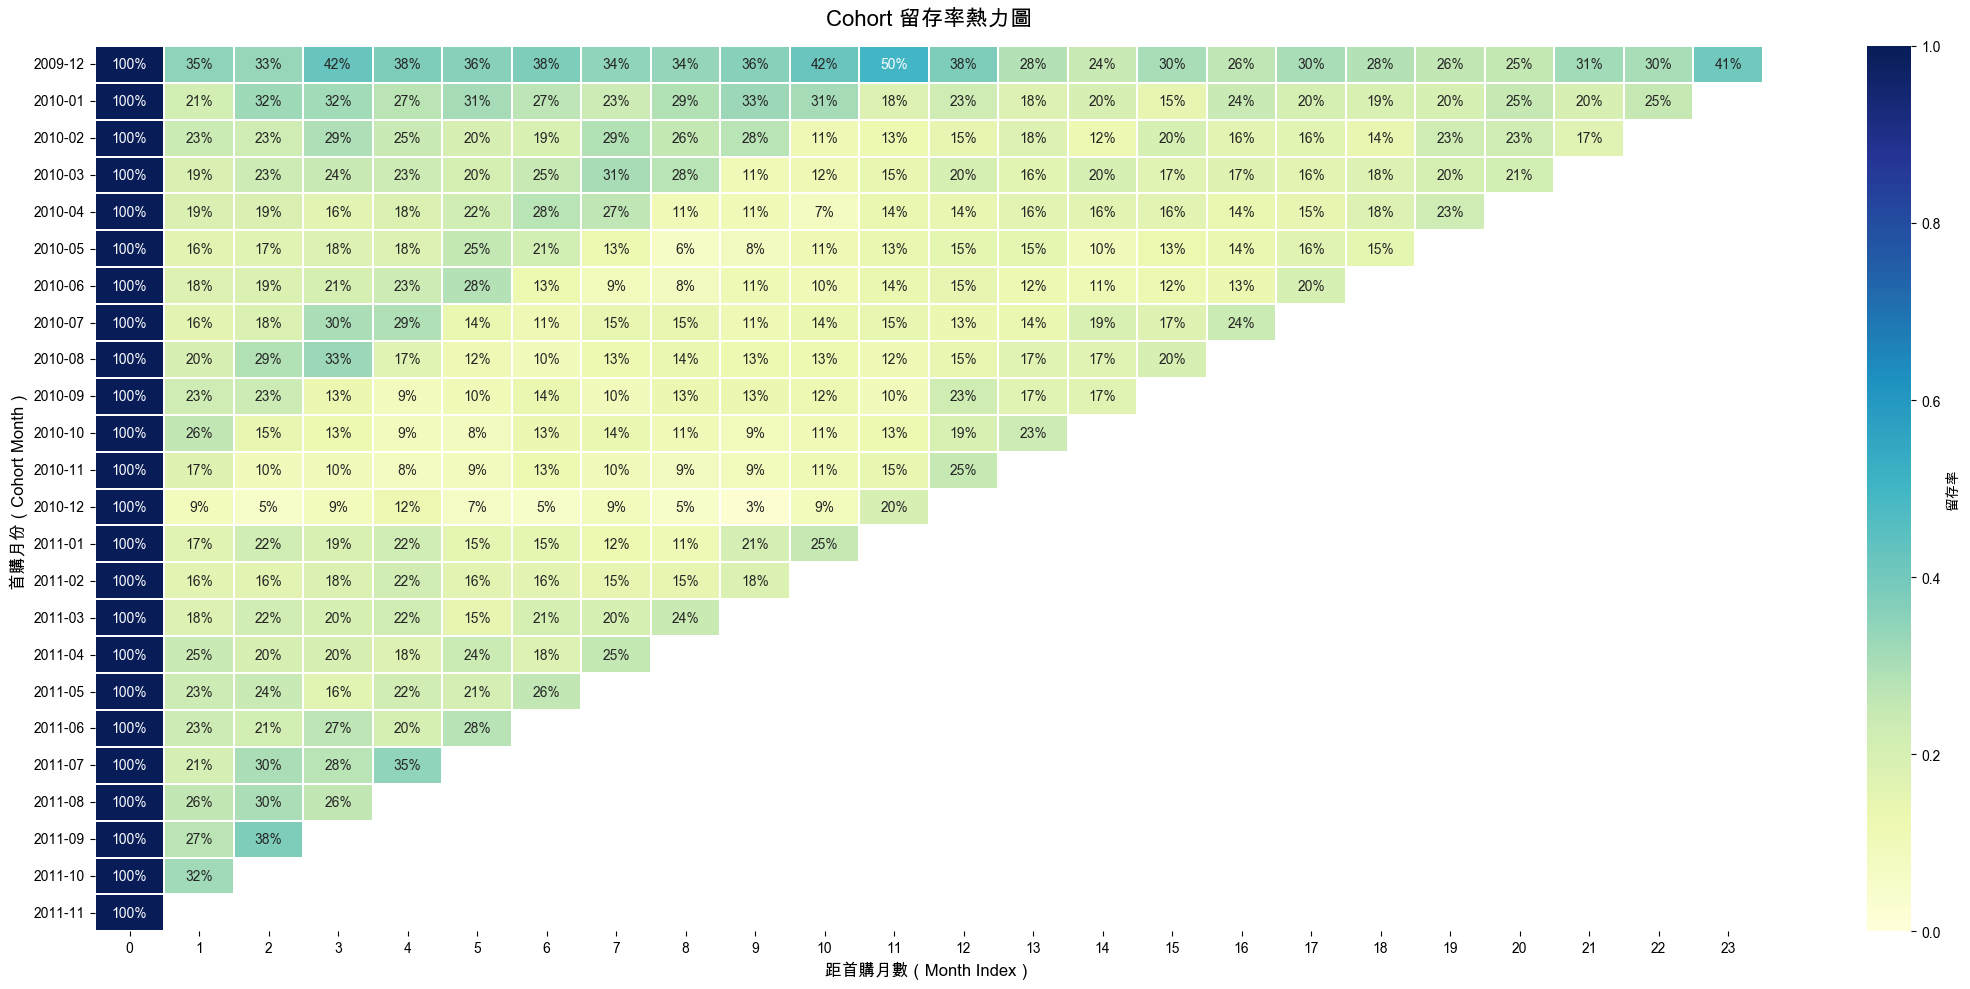

In [54]:
# 留存率熱力圖
plt.figure(figsize=(22, 10))

sns.heatmap(
    retention,
    annot=True,
    fmt='.0%',
    cmap='YlGnBu',
    linewidths=0.3,
    linecolor='white',
    vmin=0, vmax=1,
    cbar_kws={'label': '留存率'}
)

plt.title('Cohort 留存率熱力圖', fontsize=16, pad=15)
plt.xlabel('距首購月數（Month Index）', fontsize=12)
plt.ylabel('首購月份（Cohort Month）', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Cohort分析發現幾個現象：
- 月留存率整體偏低，符合批發商長採購週期的正常行為模式。
-  Cohort 的長期採購趨勢大致穩定，沒有出現某一批客群集體停止採購的跡象，代表平台的批發商客戶基礎紮實。
- 可觀察到10,11月節慶季購物的客戶明顯增加，並非反映真實的客戶黏著度提升。
- 由於資料僅涵蓋兩年且有明顯季節性效應，加上尾端 Cohort 可追蹤月數不足，故不適合繼續以平均留存率進行跨月份的統計比較。

## PART 4：RFM分析

### 方法1：五分位數法
- 將RFM三個維度分別以分位數劃分成五個區間，並以落在哪個區間來轉化為1-5的分數。
- 將標準日設為資料最後一天的隔天。
- 由於頻率(F)資料型態為整數，因此會產生過多筆資料與分位數相同，導致無法確定分在哪個區間，可能會造成各區間資料比數差距過大，因此使用 rank函式 將相同數值的項目依照它們在原始資料中出現的先後順序進行排名，來確保各區間資料比數相同。


In [55]:
# 計算RFM資料

stan_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'標準日：{stan_date.date()}')

rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (stan_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

# R：Recency 越小越好（最近購買） → 分數越高越好
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1], duplicates='drop').astype(int)

# F：Frequency 越大越好 → 使用 rank 避免重複值問題
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5], duplicates='drop').astype(int)

# M：Monetary 越大越好
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5], duplicates='drop').astype(int)

display(rfm[['Recency','Frequency','Monetary','R_Score','F_Score','M_Score']].head(10))

# ── 列出 RFM 各分數對應的實際區間 ──────────────────────

def show_quantile_bins(rfm_df, column, score_column, ascending=True):
    """顯示某個 RFM 維度，各分數對應的數值區間"""
    summary = rfm_df.groupby(score_column)[column].agg(['min', 'max', 'count'])
    summary = summary.sort_index(ascending=ascending)
    summary.columns = [f'{column}_min', f'{column}_max', '客戶數']
    return summary

print("=== Recency 各分數區間 ===")
display(show_quantile_bins(rfm, 'Recency', 'R_Score'))

print("\n=== Frequency 各分數區間 ===")
display(show_quantile_bins(rfm, 'Frequency', 'F_Score'))

print("\n=== Monetary 各分數區間 ===")
display(show_quantile_bins(rfm, 'Monetary', 'M_Score'))

標準日：2011-12-10


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,326,3,77352.96,2,3,5
1,2,8,5633.32,5,4,5
2,75,5,1658.40,3,4,4
3,19,3,3678.69,5,3,5
4,310,1,294.40,2,1,2
5,375,1,300.93,2,1,2
6,36,9,1729.54,4,5,4
7,204,2,406.76,2,2,2
8,232,1,1079.40,2,1,3
9,214,2,947.61,2,2,3


=== Recency 各分數區間 ===


,Recency_min,Recency_max,客戶數
R_Score,,,
1,410,739,1163
2,188,409,1173
3,60,187,1155
4,20,59,1174
5,1,19,1187



=== Frequency 各分數區間 ===


,Frequency_min,Frequency_max,客戶數
F_Score,,,
1,1,1,1171
2,1,2,1170
3,2,4,1170
4,4,8,1170
5,8,373,1171



=== Monetary 各分數區間 ===


,Monetary_min,Monetary_max,客戶數
M_Score,,,
1,2.95,289.70,1171
2,289.78,613.08,1170
3,613.20,1231.53,1170
4,1231.54,2952.06,1170
5,2955.17,608821.65,1171


In [56]:
# 客戶分群命名
def segment_quantile(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return '冠軍客戶'
    elif r >= 3 and f >= 3 and m >= 3:
        return '忠實客戶'
    elif r >= 4 and f <= 2:
        return '新客戶'
    elif r <= 2 and f >= 3 and m >= 3:
        return '流失高價值客戶'
    elif m >= 4:
        return '高消費潛力客戶'
    elif r <= 2 and f <= 2:
        return '流失客戶'
    else:
        return '一般客戶'

rfm['Segment_Quantile'] = rfm.apply(segment_quantile, axis=1)


# 定義客戶價值排序
segment_order = ['冠軍客戶', '忠實客戶', '高消費潛力客戶', '流失高價值客戶', '一般客戶', '新客戶', '流失客戶']

# 統計表依照此順序排列
seg_summary = rfm.groupby('Segment_Quantile').agg(
    客戶數=('Customer ID', 'count'),
    平均Recency=('Recency', 'mean'),
    平均Frequency=('Frequency', 'mean'),
    平均Monetary=('Monetary', 'mean')
).round(2)

seg_summary = seg_summary.loc[segment_order]
display(seg_summary)

,客戶數,平均Recency,平均Frequency,平均Monetary
Segment_Quantile,,,,
冠軍客戶,1295,19.98,16.97,9204.91
忠實客戶,1121,72.79,5.87,2240.85
高消費潛力客戶,90,306.74,1.57,2420.64
流失高價值客戶,617,359.04,5.66,2515.30
一般客戶,828,166.21,2.35,400.65
新客戶,451,28.13,1.46,928.79
流失客戶,1450,458.38,1.24,332.19


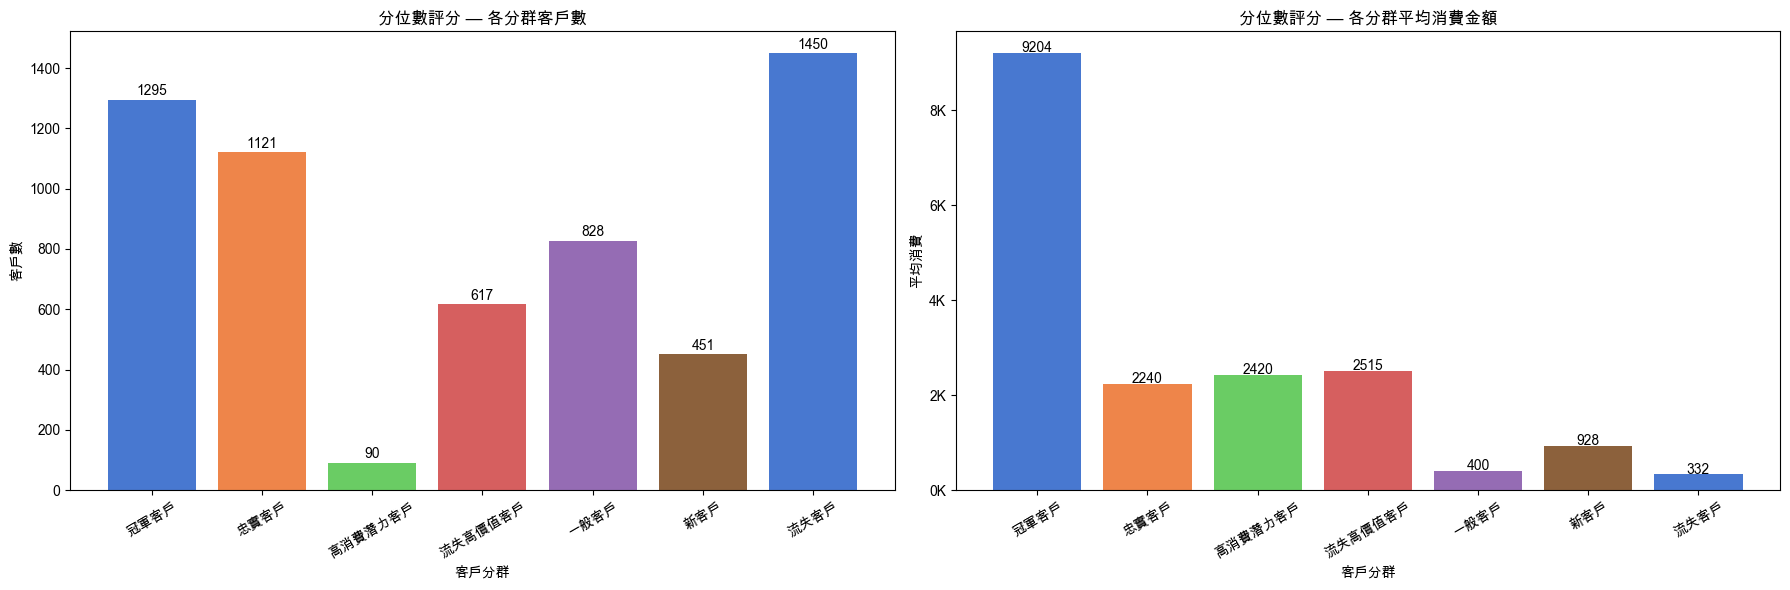

In [57]:
# 做圖
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 各分群客戶數
seg_count = rfm['Segment_Quantile'].value_counts()
seg_count = seg_count.reindex(segment_order)
axes[0].bar(seg_count.index, seg_count.values, color=sns.color_palette('muted',n_colors=6))
axes[0].set_title('分位數評分 — 各分群客戶數')
axes[0].set_xlabel('客戶分群')
axes[0].set_ylabel('客戶數')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(seg_count.values):
    axes[0].text(i, v + 15, str(v), ha='center', fontsize=10)

# 各分群平均消費
seg_monetary = rfm.groupby('Segment_Quantile')['Monetary'].mean()
seg_monetary = seg_monetary.reindex(segment_order)
axes[1].bar(seg_monetary.index, seg_monetary.values, color=sns.color_palette('muted',n_colors=6))
axes[1].set_title('分位數評分 — 各分群平均消費金額')
axes[1].set_xlabel('客戶分群')
axes[1].set_ylabel('平均消費')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for i, v in enumerate(seg_monetary.values):
    axes[1].text(i, v + 15, int(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

#### 小結：
分位數評分將客戶依照 RFM 三個維度的分數分為6個群體，規則明確適合作為初步分析的基準。  
但由於邊界是人為設定，並無法反映資料本身的自然群聚結構，也可能造成各群人數差異過大，  
因此進一步使用 K-Means 分群。

### 方法2：K-means分群

由於k-means是透過距離去分群，因此需要先將資料轉換過以免離群值影響分群結果。  
將資料取對數可以有效壓縮極端值的影響，標準化則是能確保三個維度在相同尺度上。   
因F和M的資料偏態係數過大，故取對數後再做標準化，而R直接做標準化。

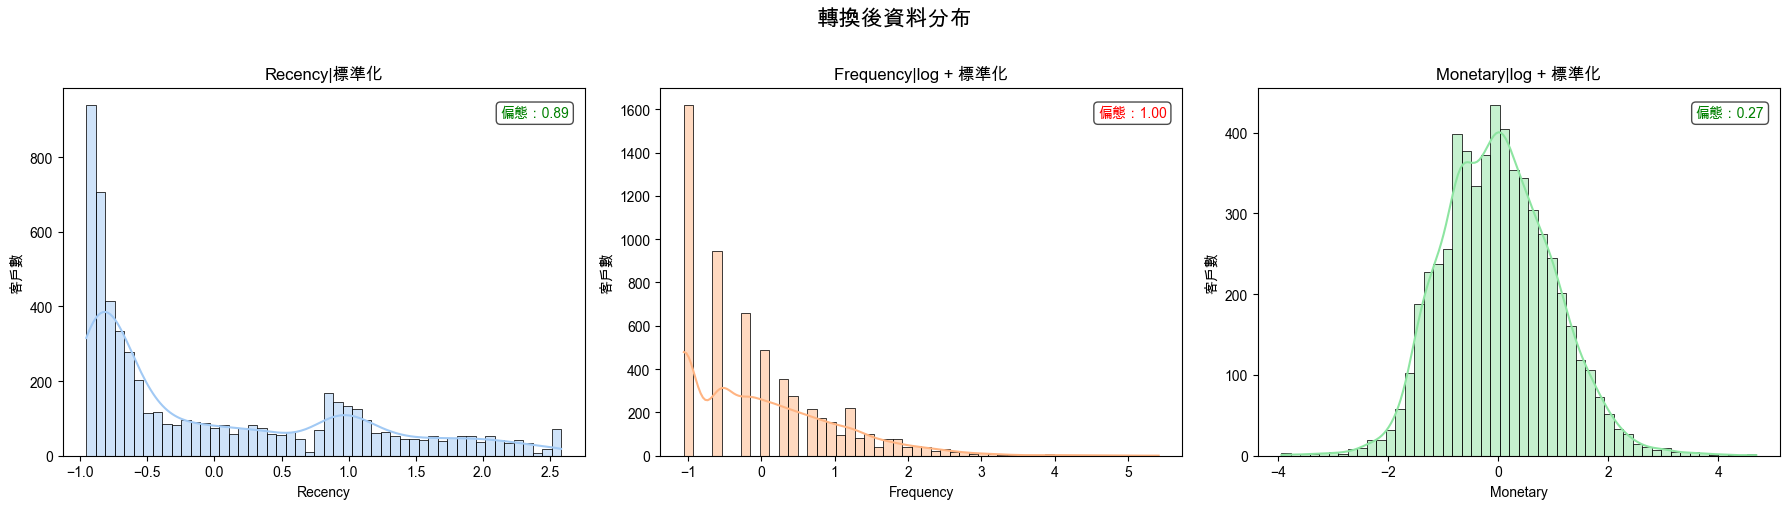

In [58]:
# 轉換資料並視覺化資料分佈

metrics = [('Recency'),('Frequency'),('Monetary')]

# 轉換資料
rfm_processed = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_processed['Frequency'] = np.log1p(rfm['Frequency'])
rfm_processed['Monetary']  = np.log1p(rfm['Monetary'])
scaler = StandardScaler()
rfm_scaled_df = pd.DataFrame(
    scaler.fit_transform(rfm_processed),
    columns=['Recency', 'Frequency', 'Monetary']
)

# 做圖
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col, metric in enumerate(metrics):

    ax_trans = axes[col]
    skew_trans = rfm_scaled_df[metric].skew()

    # 標註每個指標的處理方式
    transform_note = {
        'Recency':   '標準化',
        'Frequency': 'log + 標準化',
        'Monetary':  'log + 標準化'
    }

    sns.histplot(rfm_scaled_df[metric], bins=50, kde=True, ax=ax_trans,
                 color=sns.color_palette('pastel')[col])
    ax_trans.set_title(f'{metric}|{transform_note[metric]}')
    ax_trans.set_xlabel(metric)
    ax_trans.set_ylabel('客戶數')
    ax_trans.text(0.97, 0.95, f'偏態：{skew_trans:.2f}',
                  transform=ax_trans.transAxes, ha='right', va='top',
                  fontsize=10,
                  color='green' if abs(skew_trans) < 1 else 'red',
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

fig.suptitle('轉換後資料分布', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

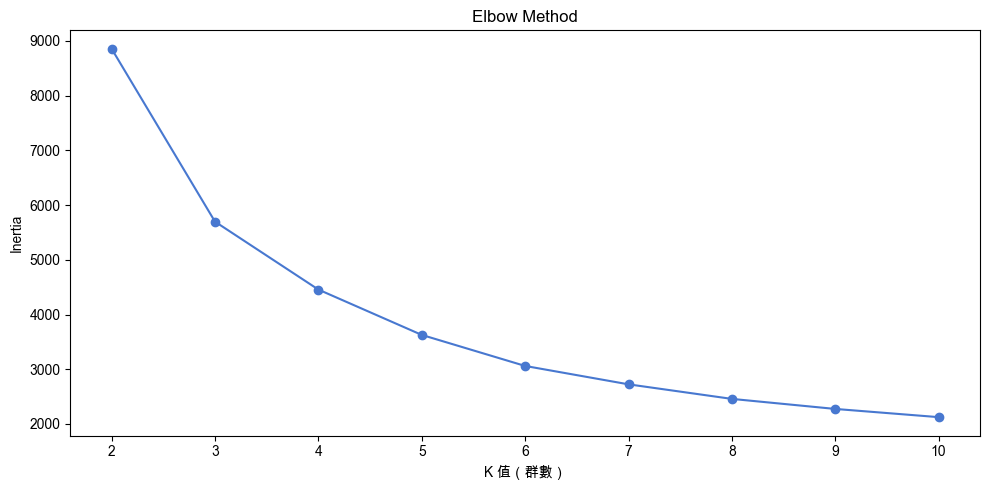

In [59]:
# 以 Elbow Method 決定最佳 K 值
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled_df)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o', color=sns.color_palette('muted')[0])
plt.title('Elbow Method')
plt.xlabel('K 值（群數）')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

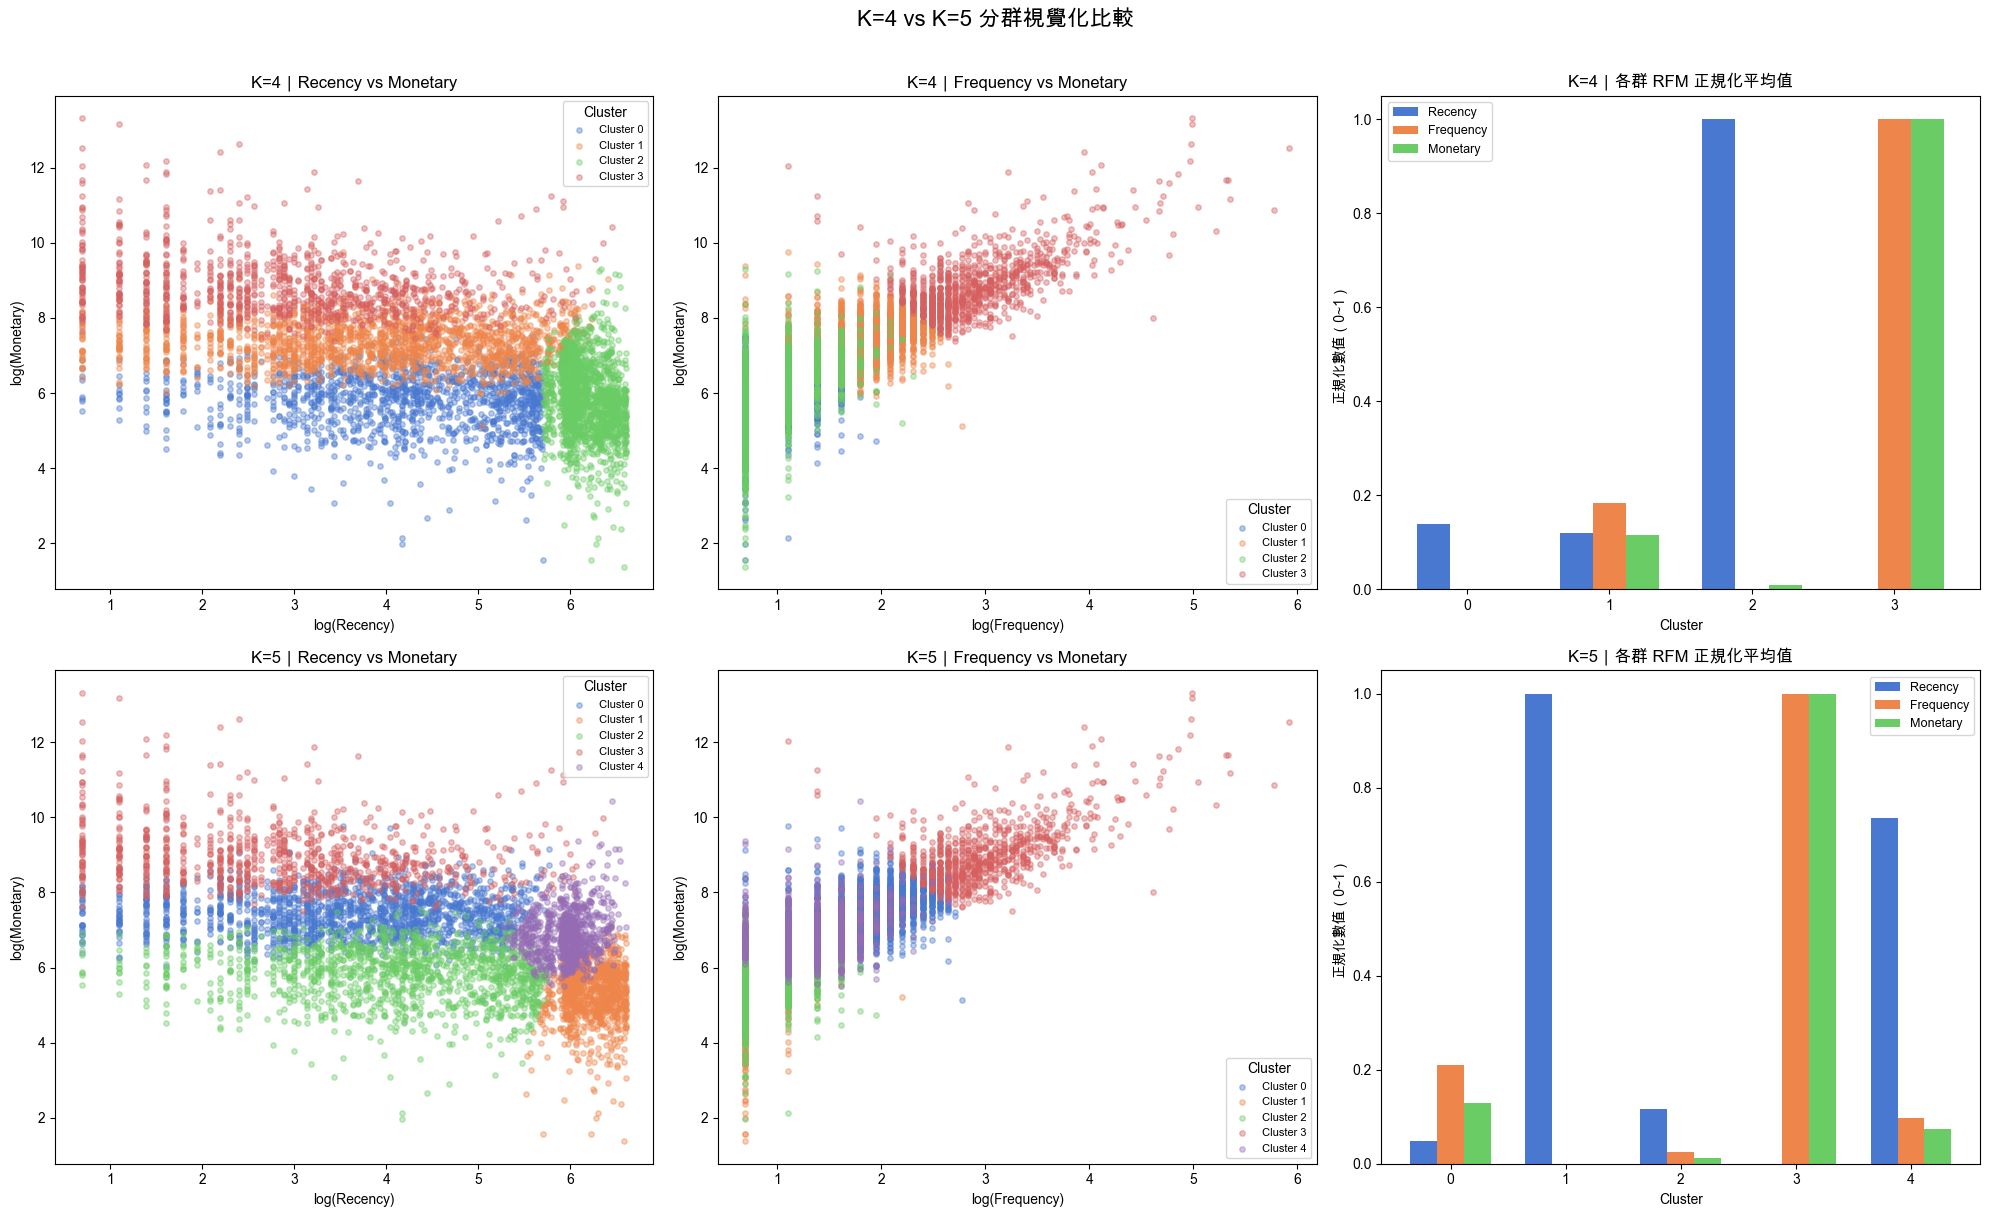

In [60]:
# 可看出在 K=4 和 K=5 較符合，做圖探討兩者差異
for k in [4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    rfm[f'Cluster_K{k}'] = km.fit_predict(rfm_scaled_df)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for row, k in enumerate([4, 5]):
    col_label = f'Cluster_K{k}'
    palette = sns.color_palette('muted', k)
    color_map = {i: palette[i] for i in range(k)}

    # --- 圖一：Recency vs Monetary 散佈圖 ---
    ax1 = axes[row][0]
    for cluster in sorted(rfm[col_label].unique()):
        group = rfm[rfm[col_label] == cluster]
        ax1.scatter(
            np.log1p(group['Recency']),
            np.log1p(group['Monetary']),
            label=f'Cluster {cluster}',
            alpha=0.4, s=15,
            color=color_map[cluster]
        )
    ax1.set_title(f'K={k}｜Recency vs Monetary')
    ax1.set_xlabel('log(Recency)')
    ax1.set_ylabel('log(Monetary)')
    ax1.legend(title='Cluster', fontsize=8)

    # --- 圖二：Frequency vs Monetary 散佈圖 ---
    ax2 = axes[row][1]
    for cluster in sorted(rfm[col_label].unique()):
        group = rfm[rfm[col_label] == cluster]
        ax2.scatter(
            np.log1p(group['Frequency']),
            np.log1p(group['Monetary']),
            label=f'Cluster {cluster}',
            alpha=0.4, s=15,
            color=color_map[cluster]
        )
    ax2.set_title(f'K={k}｜Frequency vs Monetary')
    ax2.set_xlabel('log(Frequency)')
    ax2.set_ylabel('log(Monetary)')
    ax2.legend(title='Cluster', fontsize=8)

    # --- 圖三：各群 RFM 平均值長條圖 ---
    ax3 = axes[row][2]
    cluster_means = rfm.groupby(col_label)[['Recency', 'Frequency', 'Monetary']].mean()
    cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
    cluster_means_norm.plot(kind='bar', ax=ax3,
                            color=sns.color_palette('muted', 3),
                            width=0.7)
    ax3.set_title(f'K={k}｜各群 RFM 正規化平均值')
    ax3.set_xlabel('Cluster')
    ax3.set_ylabel('正規化數值（0~1）')
    ax3.tick_params(axis='x', rotation=0)
    ax3.legend(['Recency', 'Frequency', 'Monetary'], fontsize=9)

fig.suptitle('K=4 vs K=5 分群視覺化比較', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

將k=4和k=5兩種分群結果透過視覺化比較，可看出在k=5時將R值較高的顧客(上次消費較久遠)以消費分成兩群，  
這有助於判斷流失客戶的潛在價值，以投入不同的資源，因此最終選擇k=5進行最終分群。

為群體命名採用動態命名＋事後驗證：   

動態命名，先將各群集的R,F,M三個值做平均後在群集間排名(1-5)，R的值越小排名越前、F和M值越大排名越前，  
將三個排名分數加總後再排序，依照下方的概念做分組  

| 群集 | 排名(R,F,M) |   
|---|---|
| 高價值客戶 | (中,高,高) |
| 一般活躍客戶 | (高,中,中) |
| 沉睡客戶 | (低,中,中) | 
| 低頻低消客戶 | (中,低,低) | 
| 深度流失客戶 | (低,低,低) |  

並依總分由高至低分配為 '高價值客戶', '一般活躍客戶', '沉睡客戶', '低頻低消客戶', '深度流失客戶'，

事後驗證，
- 確認命名數量是否為5、確認是否有重複名稱
- 高價值客戶 M值 應為前2高，深度流失客戶 R值 應該最高



In [61]:
# 動態命名

# 定義排序與顏色
segment_order = ['高價值客戶', '一般活躍客戶', '沉睡客戶', '低頻低消客戶', '深度流失客戶']
segment_colors = dict(zip(segment_order, sns.color_palette('muted', 5)))

k5_summary = rfm.groupby('Cluster_K5').agg(
    人數=('Customer ID', 'count'),
    平均Recency=('Recency', 'mean'),
    平均Frequency=('Frequency', 'mean'),
    平均Monetary=('Monetary', 'mean')
).round(2)

def name_clusters(cluster_summary: pd.DataFrame) -> dict:
    df = cluster_summary.copy().astype(float)

    df['rank_recency'] = df['平均Recency'].rank(ascending=True)    # 越小排名越前
    df['rank_freq'] = df['平均Frequency'].rank(ascending=False)    # 越大排名越前
    df['rank_monetary'] = df['平均Monetary'].rank(ascending=False) # 越大排名越前
    df['score'] = df['rank_recency'] + df['rank_freq'] + df['rank_monetary']

    sorted_clusters = df.sort_values('score').index.tolist()

    return dict(zip(sorted_clusters, segment_order))

cluster_name_map = name_clusters(k5_summary)
rfm['Segment_KMeans'] = rfm['Cluster_K5'].map(cluster_name_map)


In [62]:
# 驗證命名是否正確

def check_cluster(cluster_name_map: dict, expected_names: list, n_clusters: int):
    if len(cluster_name_map) != n_clusters:
        raise ValueError(f"mapping 數量({len(cluster_name_map)}) 與 cluster 數量({n_clusters}) 不符")

    mapped_names = list(cluster_name_map.values())
    if len(set(mapped_names)) != len(mapped_names):
        raise ValueError(f"名稱重複：{mapped_names}")

    if set(mapped_names) != set(expected_names):
        missing = set(expected_names) - set(mapped_names)
        extra = set(mapped_names) - set(expected_names)
        raise ValueError(f"名稱不符預期，缺少：{missing}，多餘：{extra}")

    print(f"Cluster驗證通過：{cluster_name_map}!!")


def check_logic(cluster_name_map: dict) -> bool:

    df = rfm.groupby(rfm['Cluster_K5']).agg(
        avg_recency=("Recency", "mean"),
        avg_frequency=("Frequency", "mean"),
        avg_monetary=("Monetary", "mean"),
    )
    df['segment_name'] = df.index.map(cluster_name_map)

    top2_monetary = df.nlargest(2, 'avg_monetary').index.tolist()
    high_value = df[df['segment_name'] == '高價值客戶'].index.tolist()
    check1 = set(high_value).issubset(set(top2_monetary))

    max_recency_cluster = df['avg_recency'].idxmax()
    churned = df[df['segment_name'] == '深度流失客戶'].index.tolist()
    check2 = max_recency_cluster in churned

    if not (check1 and check2):
        print(f"邏輯檢查未通過，請確認本次命名結果：{cluster_name_map}!!!!")
        return False

    print("邏輯驗證通過")
    return True

check_cluster(cluster_name_map, segment_order, n_clusters=5)
check_logic(cluster_name_map) 

Cluster驗證通過：{3: '高價值客戶', 0: '一般活躍客戶', 4: '沉睡客戶', 2: '低頻低消客戶', 1: '深度流失客戶'}!!
邏輯驗證通過


True

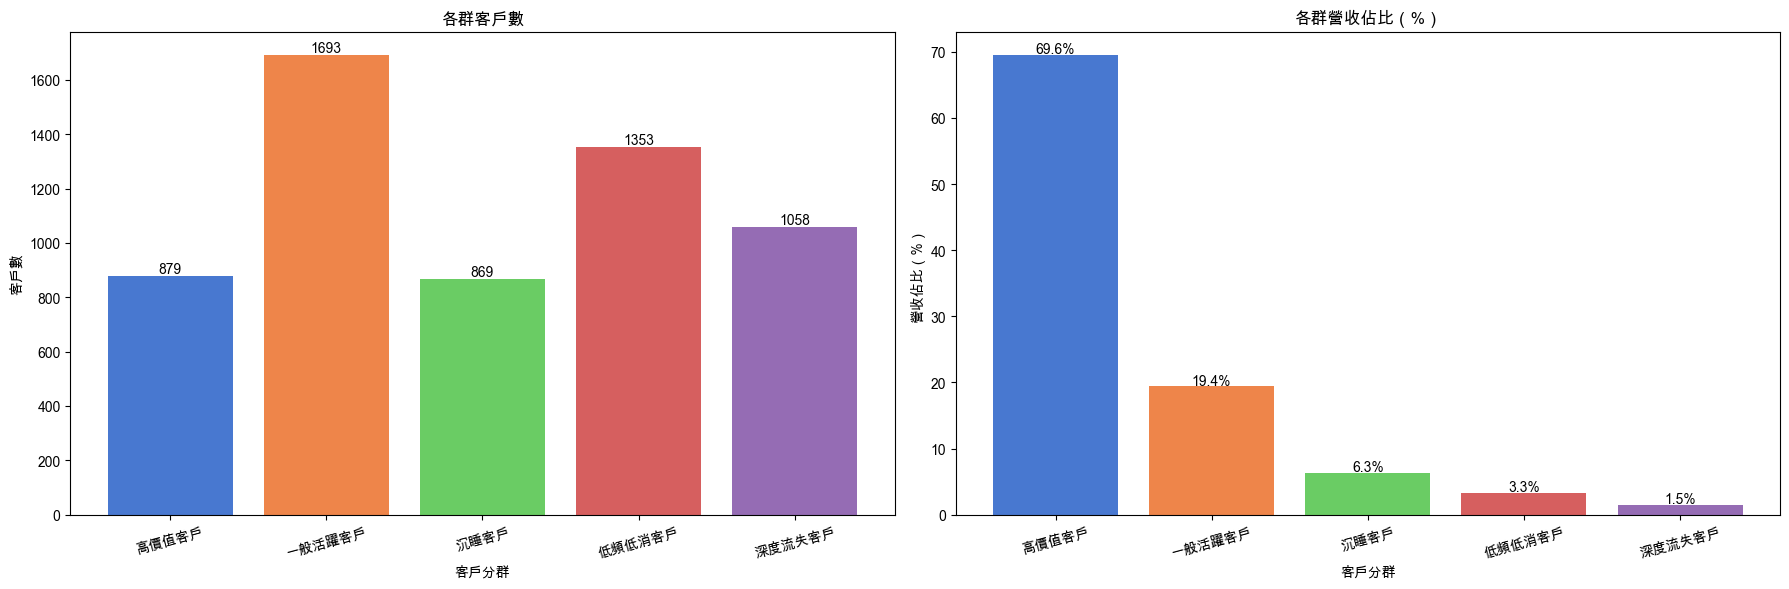

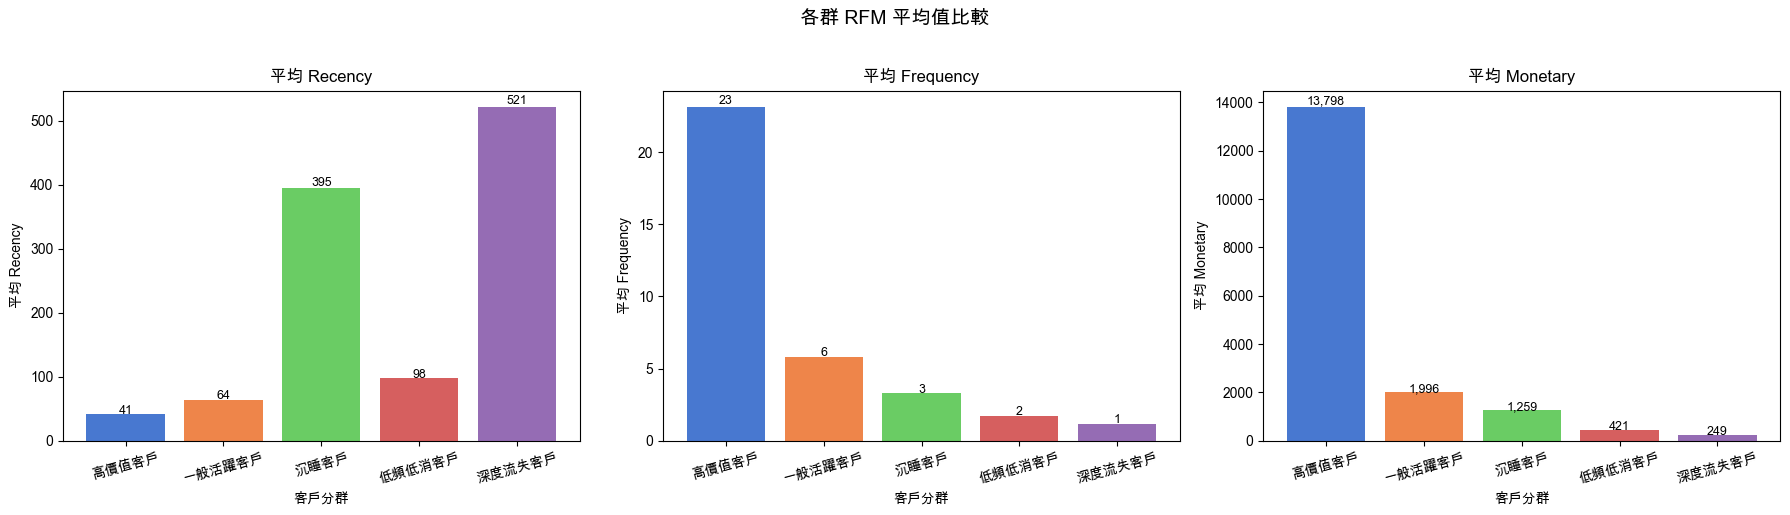

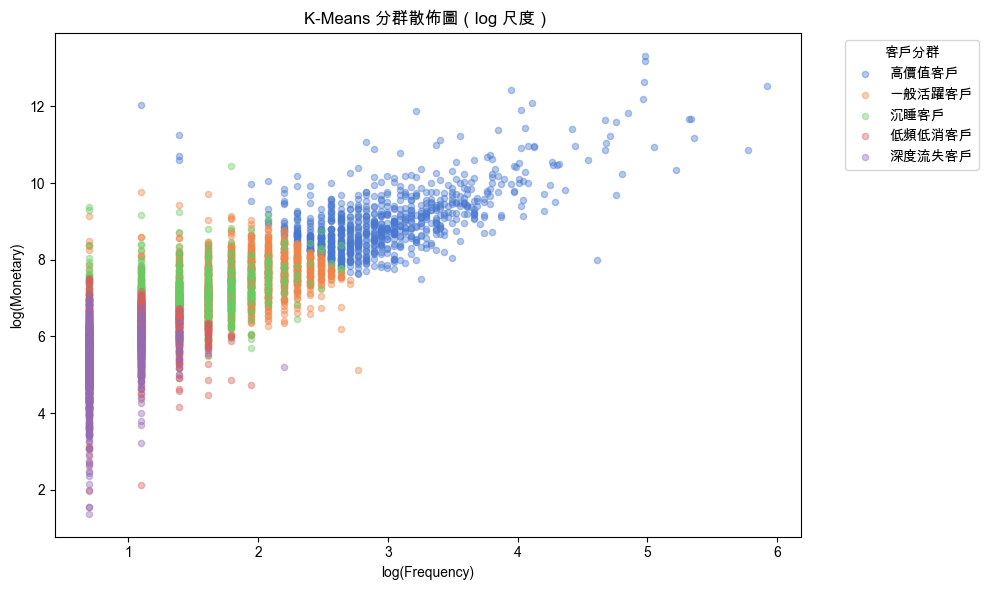

,人數,營收佔比(%),平均Recency,平均Frequency,平均Monetary
Segment_KMeans,,,,,
高價值客戶,879,69.57%,41.3,23.1,"13,798.11"
一般活躍客戶,"1,693",19.38%,64.2,5.8,"1,995.55"
沉睡客戶,869,6.28%,394.9,3.3,"1,259.17"
低頻低消客戶,"1,353",3.27%,97.5,1.7,421.13
深度流失客戶,"1,058",1.51%,521.3,1.2,249.00


In [63]:
# 做圖

# 圖一：各群客戶數與營收佔比 
seg_stats = rfm.groupby('Segment_KMeans').agg(
    人數=('Customer ID', 'count'),
    總營收=('Monetary', 'sum'),
    平均Recency=('Recency', 'mean'),
    平均Frequency=('Frequency', 'mean'),
    平均Monetary=('Monetary', 'mean')
).reindex(segment_order)
seg_stats['營收佔比(%)'] = (seg_stats['總營收'] / seg_stats['總營收'].sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 客戶數長條圖
bars = axes[0].bar(
    seg_stats.index, seg_stats['人數'],
    color=[segment_colors[s] for s in seg_stats.index]
)
axes[0].set_title('各群客戶數')
axes[0].set_xlabel('客戶分群')
axes[0].set_ylabel('客戶數')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, seg_stats['人數']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(val), ha='center', fontsize=10)

# 營收佔比長條圖
bars2 = axes[1].bar(
    seg_stats.index, seg_stats['營收佔比(%)'],
    color=[segment_colors[s] for s in seg_stats.index]
)
axes[1].set_title('各群營收佔比（%）')
axes[1].set_xlabel('客戶分群')
axes[1].set_ylabel('營收佔比（%）')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, seg_stats['營收佔比(%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


# 圖二：各群 RFM 平均值比較 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric, label) in zip(axes, [
    ('平均Recency', '平均 Recency'),
    ('平均Frequency', '平均 Frequency'),
    ('平均Monetary', '平均 Monetary'),
]):
    bars = ax.bar(
        seg_stats.index, seg_stats[metric],
        color=[segment_colors[s] for s in seg_stats.index]
    )
    ax.set_title(label)
    ax.set_xlabel('客戶分群')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, seg_stats[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:,.0f}', ha='center', fontsize=9)

plt.suptitle('各群 RFM 平均值比較', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# 圖三：散佈圖（Frequency vs Monetary）
plt.figure(figsize=(10, 6))
for seg in segment_order:
    group = rfm[rfm['Segment_KMeans'] == seg]
    plt.scatter(
        np.log1p(group['Frequency']),
        np.log1p(group['Monetary']),
        label=seg, alpha=0.4, s=20,
        color=segment_colors[seg]
    )
plt.title('K-Means 分群散佈圖（log 尺度）')
plt.xlabel('log(Frequency)')
plt.ylabel('log(Monetary)')
plt.legend(title='客戶分群', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#  表格：完整分群統計
display(
    seg_stats[['人數', '營收佔比(%)', '平均Recency', '平均Frequency', '平均Monetary']]
    .style
    .format({
        '人數': '{:,.0f}',
        '營收佔比(%)': '{:.2f}%',
        '平均Recency': '{:.1f} ',
        '平均Frequency': '{:.1f} ',
        '平均Monetary': '{:,.2f}',
    })
    .background_gradient(subset=['營收佔比(%)'], cmap='YlGnBu')
    .set_caption('各群統計摘要')
)

#### 小結：
- 高價值客戶僅佔 15% 的客戶數，卻貢獻了 69.57% 的總營收，是平台最需要優先維護的核心客群。
- 低頻低消客戶和深度流失客戶合計佔 41.2% 的客戶數，但營收佔比合計只有 4.78%，對這兩群客戶投放資源的投報率較低。
- 沉睡客戶的平均消費金額為1259.17，過去有真實的採購能力，為資源投入的優先對象。

In [64]:
comparison = rfm.groupby(['Segment_Quantile', 'Segment_KMeans']).size().unstack(fill_value=0)
display(comparison)

Segment_KMeans,一般活躍客戶,低頻低消客戶,沉睡客戶,深度流失客戶,高價值客戶
Segment_Quantile,,,,,
一般客戶,33,614,126,55,0
冠軍客戶,573,0,0,0,722
忠實客戶,925,80,0,0,116
新客戶,29,421,0,0,1
流失客戶,0,223,226,1001,0
流失高價值客戶,108,4,463,2,40
高消費潛力客戶,25,11,54,0,0


#### RFM總結：
兩種分群法在極端客群（高價值客戶,深度流失客戶）的識別較相似，  
而五分位數法由於分群的標準較被人為影響，例如冠軍客戶在K-Means法中被進一步拆分為一般活躍客戶和高價值客戶，  
而K-Means法更能提供較細緻的區隔，這在差異化行銷策略中能提供更多價值。

## PART 5 ： 總結

---

### 1. 兩個分析的發現整理

#### Cohort 分析
客戶的月留存率整體落在 15-25%，
符合長採購週期的正常行為模式，不應解讀為大量客戶流失。
從熱力圖可觀察到各 Cohort 的長期採購趨勢大致穩定，
沒有出現某一批客群集體停止採購的跡象，代表平台的批發商客戶基礎紮實。
第四季（10-11月）前後的採購活躍度明顯提升，
反映批發商節慶備貨的季節性採購規律，是全年最關鍵的業務維繫窗口。

#### RFM 分群

| 客群 | 客戶數 | 營收佔比 | 平均Recency | 平均Frequency | 平均Monetary |
|---|---|---|---|---|---|
| 高價值客戶 | 879 | 69.57% | 41.3 天 | 23.1 次 | 13,798 |
| 一般活躍客戶 | 1,693 | 19.38% | 64.2 天 | 5.8 次 | 1,996 |
| 沉睡客戶 | 869 | 6.28% | 394.9 天 | 3.3 次 | 1,259 |
| 低頻低消客戶 | 1,353 | 3.27% | 97.5 天 | 1.7 次 | 421 |
| 深度流失客戶 | 1,058 | 1.51% | 521.3 天 | 1.2 次 | 249 |

---

### 2. 關鍵發現

- **營收高度集中於少數高價值批發商**

高價值客戶僅佔 15% 的客戶數，卻貢獻了高達 69.57% 的總營收。
這批核心批發商是平台營收最關鍵的支柱。
維繫這批客戶的穩定採購關係，應是 CRM 策略的首要優先項目。

- **超過 40% 的客戶屬於低貢獻群體**

低頻低消客戶（23.1%）與深度流失客戶（18.1%）合計佔 41.2% 的客戶數，
但兩群合計的營收佔比僅 4.78%。
若對這兩群無差別投放行銷資源，投報率將極為低落，
應將資源重新分配至更具價值的客群。

- **沉睡客戶具備優先喚回價值**

沉睡客戶的歷史平均消費金額（1,259）為深度流失客戶（249）的 5 倍，
代表這群客戶過去具備真實的採購能力。
結合 Cohort 分析顯示 Q4 是批發商的集中備貨季，
建議在 Q4 前主動聯繫沉睡客戶。

- **Q4 是最關鍵的業務維繫窗口**

Cohort 分析顯示 10-11 月的採購活躍度明顯高於其他月份，
結合批發商節慶備貨的採購規律，
Q4 前的主動聯繫與報價是維繫所有客群關係的最佳時機，
尤其對高價值客戶與沉睡客戶應優先安排業務拜訪。

---

### 3. 差異化行銷資源分配建議

#### 各客群策略

| 客群 | 策略方向 | 具體行動 | 建議時機 |
|---|---|---|---|
| 高價值客戶 | 深度關係維繫 | 專屬業務對接、優先供貨保障、年度採購合約優惠 | 全年持續，Q4 前加強聯繫 |
| 一般活躍客戶 | 提升採購規模 | 階梯式批量折扣、新品優先試訂機會 | 每季主動聯繫 |
| 沉睡客戶 | 主動重啟合作 | 業務電話聯繫、了解停止採購原因、提供試單優惠 | Q4 前優先觸及，距上次採購超過 6 個月時觸發 |
| 低頻低消客戶 | 低成本維持 | 季度電子報、新品資訊推播 | 僅 Q4 節慶季主動觸及 |
| 深度流失客戶 | 停止主動投入 | 移出主動行銷名單，資源重新分配 | — |



---

### 4. 分析限制

- **資料時間不足**：資料僅涵蓋兩年，不足以完整觀察批發商的長期採購週期
  ，Cohort 的長期趨勢解讀需保守看待

- **市場集中度高**：資料以英國市場為主（約 87%），
  分群結果與商業建議的適用範圍以英國市場為主，
  未必適用其他市場的批發商行為模式

- **缺乏客戶產業別資訊**：無法進一步細分不同類型批發商
  （餐飲業、零售業、禮品業等）的採購行為差異，
  商業建議僅能停留在整體客群層次

- **月留存率的局限性**：對批發商而言，
  季度或半年度留存率是更適合的衡量指標，
  月留存率僅作為趨勢參考，不宜與零售業標準直接比較

---

### 5. 後續延伸方向

- **CLTV 預測（Customer Lifetime Value）**

使用 BG/NBD 模型預測每位批發商客戶的未來採購次數，
搭配 Gamma-Gamma 模型估算未來消費金額，
讓資源分配從「歷史行為導向」升級為「未來價值導向」，
對預算分配的依據更具前瞻性。

- **A/B Testing 驗證介入效果**

針對沉睡客戶的挽回策略設計 A/B Test，
比較「主動業務電話聯繫」vs「優惠券 EDM」的喚回效果，
以數據驗證最有效的介入方式，避免策略依賴主觀判斷。

- **季度 Cohort 分析**

搜集更長時間的資料，並將目前的月度 Cohort 改為季度 Cohort，
更符合批發商的實際採購週期，
能更準確地識別採購萎縮的客群，
提升 Cohort 分析的解釋力。